In [1]:
from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings, 
    LinearElasticIsotropic, 
    MaterialAssignment, 
    ProblemSettings
)
from homicsx.geometry import patriculate_geometry_generator
from homicsx.visualization import visualize_geometry
from homicsx.mesh import generate_mesh
from homicsx.homogenization import solve_linear_homogenization
from homicsx.utils import (
    extract_effective_moduli_3d, 
)

import numpy as np

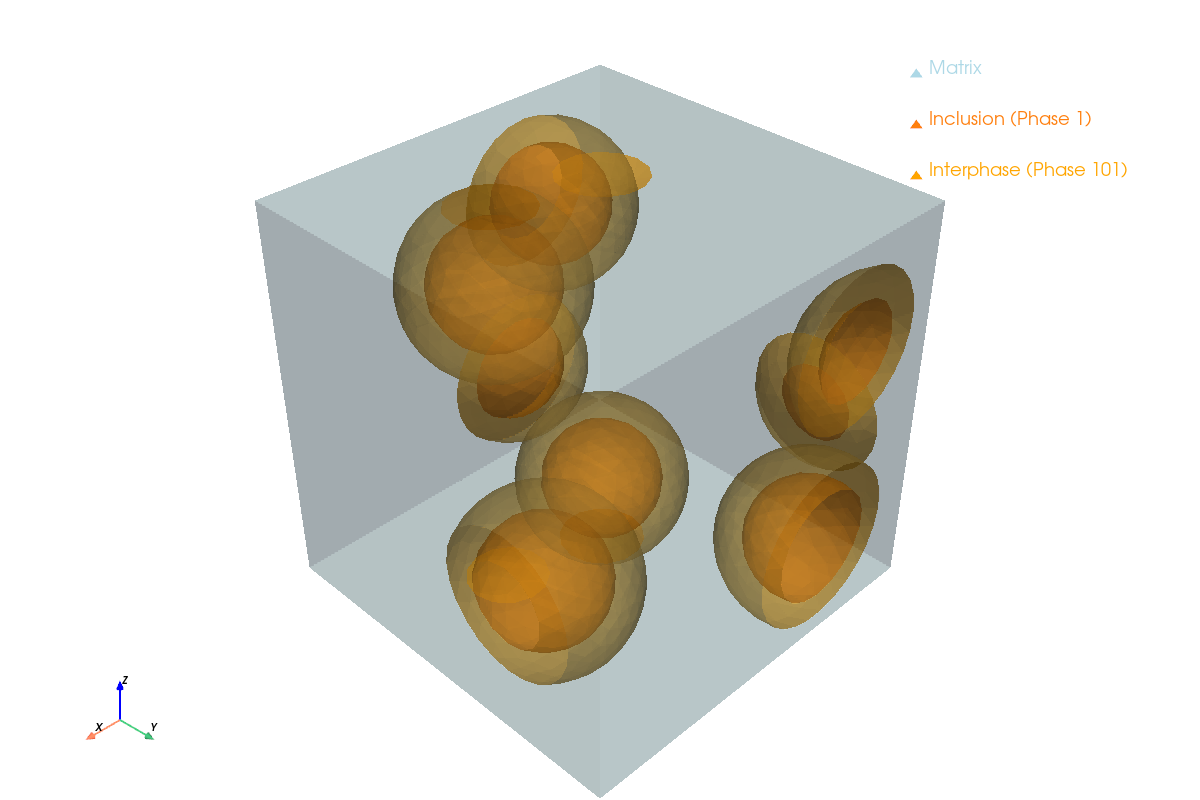

(0, 1, 101)


In [2]:
geometry_input = GeometryInput(
    dim=3,
    dispersion='mono',
    shape='sphere',
    volume_fraction=0.2,
    clearance=0.02,
    domain_size=(1, 1, 1),
    num_particles=5,
    interphase_thickness_ratio=0.3,
)

geom = patriculate_geometry_generator(geometry_input)

visualize_geometry(geom)

print(geom.phase_ids)

In [3]:
physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.03,
    max_size=0.04,
    physical_tags=physical_tags,
)

mesh, ct, ft = generate_mesh(
    geometry=geom,
    mesh_settings=mesh_settings,
)

In [4]:
E_mat = 1.0
nu_mat = 0.3
mat_mat = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 100.0
nu_inc = 0.3
mat_inc = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

E_int = 10.0
nu_int = 0.3
mat_int = LinearElasticIsotropic(young_modulus=E_int, poisson_ratio=nu_int)

material_assignment = MaterialAssignment(
    materials_by_phase={
        geom.phase_ids[0]: mat_mat,
        geom.phase_ids[1]: mat_inc,
        geom.phase_ids[2]: mat_int,
    }
)

In [5]:
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='small_strain',
    element_family='Lagrange',
    element_degree=1,
    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
)

In [6]:
result = solve_linear_homogenization(
    mesh_obj=mesh,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=geometry_input.domain_size,
    matrix_phase_id=0,
    mode='complete',
)

C_hom = result.C_hom
print('C_hom: ')
with np.printoptions(suppress=True, precision=3):
    print(C_hom)

C_hom: 
[[ 1.814  0.728  0.724  0.012 -0.008  0.004]
 [ 0.729  1.807  0.717  0.013  0.    -0.002]
 [ 0.723  0.718  1.868  0.002 -0.015  0.003]
 [ 0.012  0.012  0.002  0.542  0.006 -0.003]
 [-0.01  -0.001 -0.016  0.005  0.545  0.007]
 [ 0.004 -0.001  0.003 -0.003  0.008  0.536]]


In [ ]:
kappa_hom, mu_hom, E_hom, nu_hom = extract_effective_moduli_3d(C_hom)

print('summary:')
print('-'*20)
print('Young modulus:')
print(f'homogenization result: {E_hom}')
print('-'*20)
print('Poison ratio:')
print(f'homogenization result: {nu_hom}')

summary:
--------------------
Young modulus:
homogenization result: 1.3958892570432202
--------------------
Poison ratio:
homogenization result: 0.28656687296894595


: 